# DEtection TRansformer (DETR)

Pros:

1. No region proposal tuning
2. Sigle stage pipeline
3. Single loss function

Cons:

1.   Data hungry
2.   Strugles with small objects
3.   Too big to fit in mobile


Requires:

> The follicle data be loaded into drive or directly into colab runtime environment.
> The fine-tuned model is in my drive. I can share if needed (to avoid re-trianing).

Key Param:

The number of decoder queries is set to 100. Given that the median number of objects per image is 12, this value can be reduced to help minimize overlapping predictions.



In [1]:
import os
import xml.etree.ElementTree as ET
from dataclasses import dataclass
from typing import List, Dict, Any

import torch
from torch.utils.data import Dataset
from PIL import Image, ImageDraw, ImageFont

from transformers import (
    DetrImageProcessor,
    DetrForObjectDetection,
    TrainingArguments,
    Trainer
)

import pandas as pd
import matplotlib.pyplot as plt
import json


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!cp -r /content/drive/MyDrive/data /content/


In [4]:
# ============================================================
# CONFIG: setting params
# ============================================================

@dataclass
class Config:
    train_image_dir: str = "/content/data/Images"
    train_annot_dir: str = "/content/data/Annotations"

    pretrained_model_name: str = "facebook/detr-resnet-50"
    output_dir: str = "./detr_voc_finetuned"

    class_names: List[str] = None
    image_size: int = 800

    per_device_train_batch_size: int = 2
    per_device_eval_batch_size: int = 2
    num_train_epochs: int = 5
    learning_rate: float = 1e-4
    weight_decay: float = 1e-4
    num_workers: int = 2
    save_total_limit: int = 2

    def __post_init__(self):
        # Replace with your actual classes
        if self.class_names is None:
            self.class_names = ['premium','single','undersize','abnormal']


cfg = Config()

# IMPORTANT:
# Pascal VOC class ids must start from 0
id2label = {i: name for i, name in enumerate(cfg.class_names)}
label2id = {name: i for i, name in id2label.items()}


In [5]:
# load training and validation file names
train_files =[]
val_files = []
with open('/content/data/ImageSets/Main/train.txt') as f:
    lines = f.readlines()
    train_files =[fnm[:-1] for fnm in lines]

with open('/content/data/ImageSets/Main/val.txt') as f:
    lines = f.readlines()
    val_files =[fnm[:-1] for fnm in lines]

In [6]:

# ============================================================
# XML Parser and bbox fixer
# ============================================================

def clip_box_xyxy(box, width, height):
    x1, y1, x2, y2 = box
    x1 = max(0.0, min(float(x1), width - 1))
    y1 = max(0.0, min(float(y1), height - 1))
    x2 = max(0.0, min(float(x2), width - 1))
    y2 = max(0.0, min(float(y2), height - 1))
    return [x1, y1, x2, y2]

def is_valid_xyxy(box):
    x1, y1, x2, y2 = box
    return (x2 > x1) and (y2 > y1)

def xyxy_to_xywh(box):
    x1, y1, x2, y2 = box
    return [x1, y1, x2 - x1, y2 - y1]

def parse_voc_xml(xml_path: str, label2id: Dict[str, int]) -> Dict[str, Any]:
    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.findtext("filename")
    size = root.find("size")
    width = int(size.findtext("width"))
    height = int(size.findtext("height"))

    objects = []
    for obj in root.findall("object"):
        name = obj.findtext("name")
        if name is None:
            name = obj.findtext("class")
        if name is None:
            continue

        name = name.strip().lower()
        if name not in label2id:
            continue

        bndbox = obj.find("bndbox")
        if bndbox is None:
            continue

        xmin = float(bndbox.findtext("xmin"))
        ymin = float(bndbox.findtext("ymin"))
        xmax = float(bndbox.findtext("xmax"))
        ymax = float(bndbox.findtext("ymax"))

        # Repair reversed coordinates
        x1, x2 = sorted([xmin, xmax])
        y1, y2 = sorted([ymin, ymax])

        # Clip to XML-declared image size
        x1 = max(0.0, min(x1, width - 1))
        y1 = max(0.0, min(y1, height - 1))
        x2 = max(0.0, min(x2, width - 1))
        y2 = max(0.0, min(y2, height - 1))

        if x2 <= x1 or y2 <= y1:
            continue

        difficult = obj.findtext("difficult")
        difficult = int(difficult) if difficult is not None else 0

        objects.append({
            "name": name,
            "class_id": label2id[name],
            "bbox_xyxy": [x1, y1, x2, y2],
            "difficult": difficult,
        })

    return {
        "filename": filename,
        "width": width,
        "height": height,
        "objects": objects,
    }

#create data set
class PascalVOCDataset(Dataset):
    def __init__(self, image_dir, annot_dir, processor, label2id, split):
        self.image_dir = image_dir
        self.annot_dir = annot_dir
        self.processor = processor
        self.label2id = label2id
        self.split = set(split)

        self.xml_files = sorted([
            f for f in os.listdir(annot_dir)
            if f.endswith(".xml") and os.path.splitext(f)[0] in self.split
        ])

    def __len__(self):
        return len(self.xml_files)

    def __getitem__(self, idx):
        xml_file = self.xml_files[idx]
        xml_path = os.path.join(self.annot_dir, xml_file)

        parsed = parse_voc_xml(xml_path, self.label2id)

        image_filename = parsed["filename"]
        image_path = os.path.join(self.image_dir, image_filename)

        if not os.path.exists(image_path):
            stem = os.path.splitext(xml_file)[0]
            found = False
            for ext in [".jpg", ".jpeg", ".png", ".bmp"]:
                alt_path = os.path.join(self.image_dir, stem + ext)
                if os.path.exists(alt_path):
                    image_path = alt_path
                    found = True
                    break
            if not found:
                raise FileNotFoundError(f"Image not found for XML: {xml_path}")

        image = Image.open(image_path).convert("RGB")
        width, height = image.size

        annotations = []
        ann_id = 0

        for obj in parsed["objects"]:
            box_xyxy = clip_box_xyxy(obj["bbox_xyxy"], width, height)
            if not is_valid_xyxy(box_xyxy):
                continue

            x, y, w, h = xyxy_to_xywh(box_xyxy)
            if w <= 0 or h <= 0:
                continue

            annotations.append({
                "id": ann_id,
                "image_id": idx,
                "category_id": int(obj["class_id"]),
                "bbox": [float(x), float(y), float(w), float(h)],  # COCO absolute xywh
                "area": float(w * h),
                "iscrowd": 0,
            })
            ann_id += 1

        target = {
            "image_id": idx,
            "annotations": annotations,
        }

        encoding = self.processor(
            images=image,
            annotations=target,
            return_tensors="pt",
        )

        return {
            "pixel_values": encoding["pixel_values"].squeeze(0),
            "labels": encoding["labels"][0],
        }


processor = DetrImageProcessor.from_pretrained(
    cfg.pretrained_model_name,
    size={"shortest_edge": cfg.image_size, "longest_edge": 1333},
)

# prepare data ready to be consumed by loader
def collate_fn(batch):
    pixel_values = [item["pixel_values"] for item in batch]
    labels = [item["labels"] for item in batch]

    padded = processor.pad(pixel_values, return_tensors="pt")

    return {
        "pixel_values": padded["pixel_values"],
        "pixel_mask": padded["pixel_mask"],
        "labels": labels,
    }

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [7]:
# ============================================================
# Create Dataset
# ============================================================

train_dataset = PascalVOCDataset(
    image_dir=cfg.train_image_dir,
    annot_dir=cfg.train_annot_dir,
    processor=processor,
    label2id=label2id,
    split= train_files
)

val_dataset = PascalVOCDataset(
    image_dir=cfg.train_image_dir,
    annot_dir=cfg.train_annot_dir,
    processor=processor,
    label2id=label2id,
    split= val_files
)

In [8]:


# ============================================================
# TRAINING ARGS
# ============================================================

training_args = TrainingArguments(
    output_dir=cfg.output_dir,
    per_device_train_batch_size=cfg.per_device_train_batch_size,
    per_device_eval_batch_size=cfg.per_device_eval_batch_size,
    num_train_epochs= 10, #cfg.num_train_epochs,

    learning_rate=1e-5,
    weight_decay=cfg.weight_decay,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=20,

    save_total_limit=cfg.save_total_limit,
    remove_unused_columns=False,
    dataloader_num_workers=cfg.num_workers,

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    fp16=False,
    max_grad_norm=1.0,
    warmup_steps=500,
)


In [9]:
# Fine tune a model or load from checkpoint if exists
save_path = "/content/drive/MyDrive/detr_follicle_model"
hist_path ="/content/drive/MyDrive/detr_follicle_model/training_log_history.json"
logs=''
if os.path.exists(os.path.join(save_path, "config.json")):
    print("Loading existing model from Drive...")

    model = DetrForObjectDetection.from_pretrained(save_path)
    processor = DetrImageProcessor.from_pretrained(save_path)
    with open(hist_path, "r") as f:
      logs = json.load(f)
else:
    print(" No saved model found. Training new model...")

    # ---- initialize model ----
    from transformers import DetrConfig

    config = DetrConfig.from_pretrained(cfg.pretrained_model_name)
    config.num_queries = 100
    config.num_labels = len(cfg.class_names)
    config.id2label = id2label
    config.label2id = label2id

    model = DetrForObjectDetection.from_pretrained(
        cfg.pretrained_model_name,
        config=config,
        ignore_mismatched_sizes=True
    )

    # ---- train ----
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        processing_class=processor,
        data_collator=collate_fn,
    )

    trainer.train()

    # ---- save ----
    logs= trainer.state.log_history
    trainer.save_model(save_path)          # saves model weights + config
    processor.save_pretrained(save_path)   # saves image processor

    with open(os.path.join(save_path, "training_log_history.json"), "w") as f:
      json.dump(trainer.state.log_history, f, indent=2) # save history

    print("Model saved to Drive.")

Loading existing model from Drive...


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2586: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  module._load_from_state_dict(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  super()._load_from_state_dict(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, whi

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

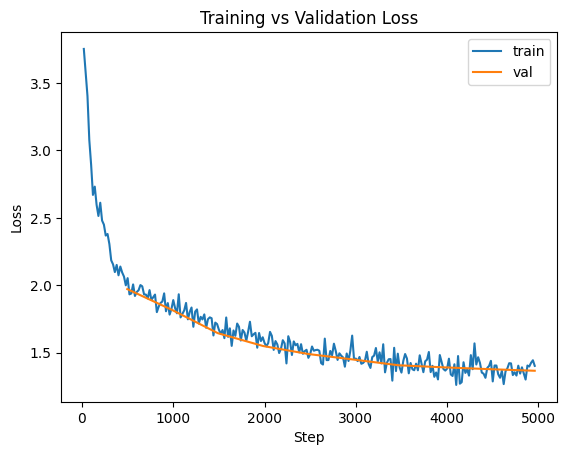

In [10]:

#logs = trainer.state.log_history
df = pd.DataFrame(logs)

train_loss = df[df["loss"].notna()]
val_loss = df[df["eval_loss"].notna()]

plt.plot(train_loss["step"], train_loss["loss"], label="train")
plt.plot(val_loss["step"], val_loss["eval_loss"], label="val")
plt.legend()
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.show()

In [11]:

# ============================================================
# INFERENCE
# ============================================================

def draw_boxes(image, boxes, labels, color, width=2):
    draw = ImageDraw.Draw(image)

    for box, label in zip(boxes, labels):
        x1, y1, x2, y2 = box
        draw.rectangle([x1, y1, x2, y2], outline=color, width=width)
        draw.text((x1, y1), label, fill=color)

    return image


def predict_and_draw(
    image_path,
    model,
    processor,
    id2label,
    gt_boxes=None,        # list of [x1,y1,x2,y2]
    gt_labels=None,       # list of class ids
    threshold=0.5,
    device=None
):
    if device is None:
        if torch.cuda.is_available():
            device = "cuda"
        elif torch.backends.mps.is_available():
            device = "mps"
        else:
            device = "cpu"

    model.to(device)
    model.eval()

    image = Image.open(image_path).convert("RGB")

    # -------- Prediction --------
    inputs = processor(images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    target_sizes = torch.tensor([image.size[::-1]], device=device)

    results = processor.post_process_object_detection(
        outputs=outputs,
        threshold=threshold,
        target_sizes=target_sizes
    )[0]

    pred_boxes = results["boxes"].cpu().numpy()
    pred_labels = results["labels"].cpu().numpy()
    pred_scores = results["scores"].cpu().numpy()

    pred_label_names = [
        f"{id2label[int(l)]}:{round(float(s),2)}"
        for l, s in zip(pred_labels, pred_scores)
    ]
    print(len(pred_boxes),len(gt_boxes))
    print(pred_scores)
    # -------- Draw --------
    image_draw = image.copy()

    # Draw ground truth (GREEN)
    if gt_boxes is not None and len(gt_boxes) > 0:
        gt_label_names = [id2label[int(l)] for l in gt_labels]
        image_draw = draw_boxes(image_draw, gt_boxes, gt_label_names, color="green")

    # Draw predictions (RED)
    image_draw = draw_boxes(image_draw, pred_boxes, pred_label_names, color="red")

    return image_draw

In [12]:
# Run test on single test image
#test
xml_path = '/content/data/Annotations/220105_A095_2.xml'
image_path = "/content/data/Images/220105_A095_2.jpg"
parsed = parse_voc_xml(xml_path, label2id)

gt_boxes = [obj["bbox_xyxy"] for obj in parsed["objects"]]
gt_labels = [obj["class_id"] for obj in parsed["objects"]]

img = predict_and_draw(
    image_path,
    model,
    processor,
    id2label,
    gt_boxes=gt_boxes,
    gt_labels=gt_labels,
    threshold=0.5
)

img.show()

19 14
[0.64537287 0.67223436 0.6141554  0.71681064 0.547079   0.6349267
 0.6206774  0.52706736 0.6237145  0.6353911  0.6080151  0.6975108
 0.72727454 0.59187514 0.6228392  0.60073274 0.7156168  0.54639214
 0.6049796 ]


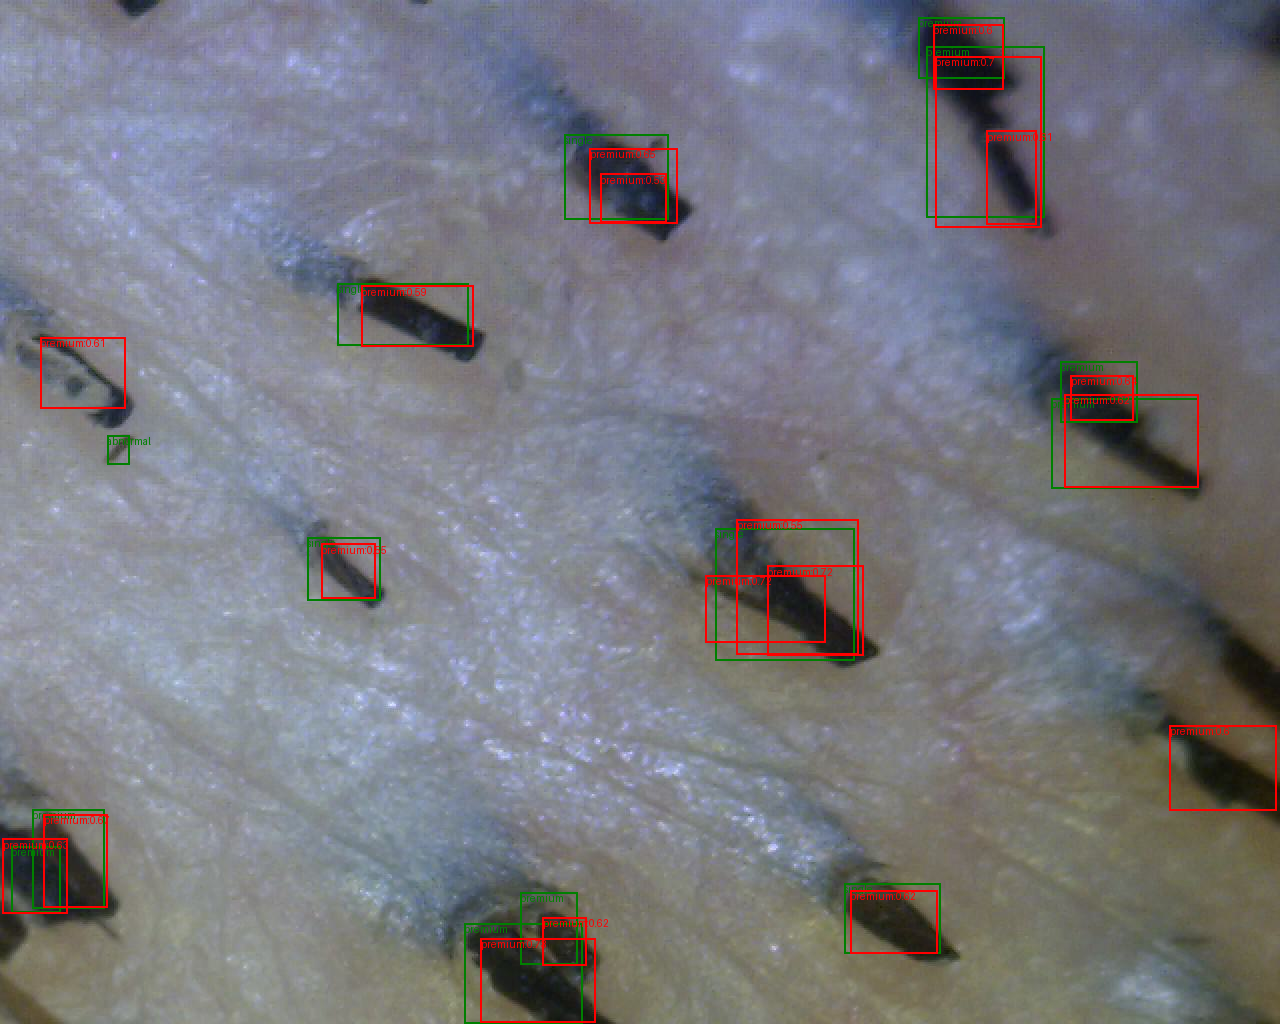

In [13]:
img

# Further work:

1. The model defaults to predicting the premium class, likely due to class imbalance. Further tuning is needed to address this issue.
2. Further tuning for better box detection